[*********************100%***********************]  5 of 5 completed



Optimal Portfolio Weights
--------------------------
TLT: 0.6346150934861376
GLD: 0.3653849065138621
SPY: 4.464192187087431e-16
QQQ: 0.0
VWO: 0.0

Portfolio Metrics
-----------------
Expected Annual Return: 19.580453206189112%
Volatility (Risk): 14.786907363299576%
Sharpe Ratio: 1.1889202234283953


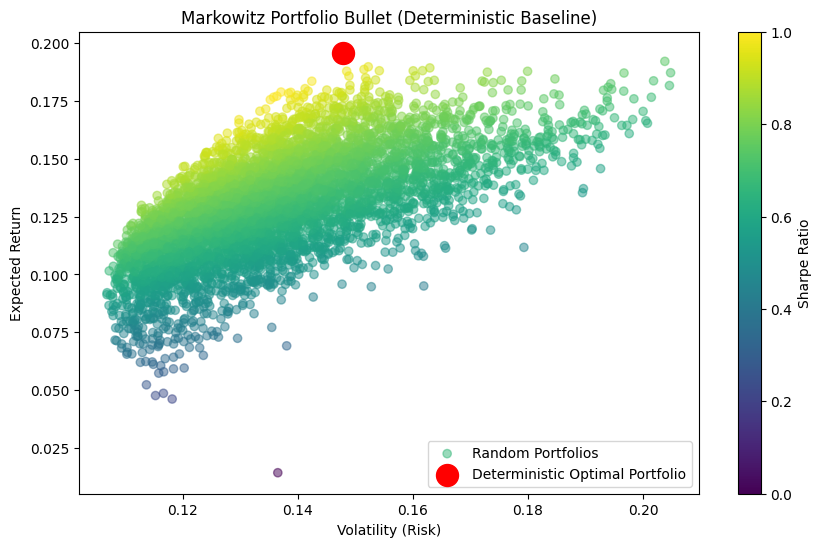

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import yfinance as yf

# Defining basic parameters and assets
# tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "AMD"]
tickers = ['TLT', 'GLD', 'SPY', 'QQQ', 'VWO']
start = "2019-01-01"
risk_free_rate = 0.02

# number of random portfolios for comparison
num_visual_samples = 5000

# Get the required data

data = yf.download(tickers, start=start)["Close"]
returns = data.pct_change().dropna()

# Annual statistics
mu = returns.mean() * 252
Sigma = returns.cov() * 252

num_assets = len(tickers)

# Basic functions to better help make the optimized portfolio

def portfolio_return(weights):
    return np.dot(weights, mu)

def portfolio_volatility(weights):
    return np.sqrt(weights.T @ Sigma @ weights)

def sharpe_ratio(weights):
    r = portfolio_return(weights)
    v = portfolio_volatility(weights)
    return (r - risk_free_rate) / v

def negative_sharpe(weights):
    return -sharpe_ratio(weights)

# Optimize the weights using a deterministic approach and function

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0,1) for _ in range(num_assets))
initial = np.ones(num_assets) / num_assets

result = minimize(
    negative_sharpe,
    initial,
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

optimal_weights = result.x

# List optimized weights

print("\nOptimal Portfolio Weights")
print("--------------------------")

for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight}")

expected_return = portfolio_return(optimal_weights)
volatility = portfolio_volatility(optimal_weights)
sharpe = sharpe_ratio(optimal_weights)

print("\nPortfolio Metrics")
print("-----------------")
print(f"Expected Annual Return: {expected_return*100}%")
print(f"Volatility (Risk): {volatility*100}%")
print(f"Sharpe Ratio: {sharpe}")

# Calculate the random portfolio returns and risk

sample_returns = []
sample_vols = []
sample_sharpes = []

for _ in range(num_visual_samples):

    w = np.random.random(num_assets)
    w /= np.sum(w)

    r = portfolio_return(w)
    v = portfolio_volatility(w)
    s = sharpe_ratio(w)

    sample_returns.append(r)
    sample_vols.append(v)
    sample_sharpes.append(s)

# Plotting the this graphically

plt.figure(figsize=(10,6))

plt.scatter(
    sample_vols,
    sample_returns,
    c=sample_sharpes,
    alpha=0.5,
    label="Random Portfolios"
)

plt.scatter(
    volatility,
    expected_return,
    color="red",
    marker="o",
    s=250,
    label="Deterministic Optimal Portfolio"
)

plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.title("Markowitz Portfolio Bullet (Deterministic Baseline)")

plt.colorbar(label="Sharpe Ratio")
plt.legend()

plt.show()